In [1]:
import pandas as pd
import glob

NUMERIC = {'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm'}

def fix(p):
    if isinstance(p,str) and p.strip().upper().startswith('VALUE:'):
        v=p.strip().split(':',1)[1].strip()
        return 'UNKNOWN' if v.upper() in {'UNKNOWN','NONE','NULL','NAN',''} else v
    return p

def is_unk(v): return str(v).strip().lower() in {'unknown','nan','none','null',''}

def correct(pred,gt,attr):
    if is_unk(pred): return False
    if attr in NUMERIC:
        try: return float(str(pred).replace(',',''))==float(str(gt).replace(',',''))
        except: return False
    p,g=str(pred).lower().strip(),str(gt).lower().strip()
    return p==g or p in g or g in p

configs = [
    ('Exp 1 LLM-only',           'results_mit_UNKNOWN/exp1_llm_only.csv'),
    ('Exp 2 RAG-MiniLM',         'results_mit_UNKNOWN/exp2_rag_minilm.csv'),
    ('Exp 3 MiniLM+RR',          'results_mit_UNKNOWN/exp3_rag_minilm_reranker.csv'),
    ('Exp 4 BGE+RR Llama',       'results_mit_UNKNOWN/exp4_rag_bge_reranker.csv'),
    ('Exp 5 TE+RR Llama',        'results_mit_UNKNOWN/exp5_rag_te_reranker.csv'),
    ('Exp 6 BGE+RR GPT-4o-mini', 'results_mit_UNKNOWN/exp6_bge_reranker_gpt4omini.csv'),
    ('Exp 7 TE+RR GPT-4o-mini',  'results_mit_UNKNOWN/exp7_te_reranker_gpt4omini.csv'),
    ('Exp 8 BGE+RR GPT-5.4-mini','results/exp6_bge_reranker_gpt-5.4-mini.csv'),
    ('Exp 9 TE+RR GPT-5.4-mini', 'results/exp7_te_reranker_gpt-5.4-mini.csv'),
]

print(f'{"Config":<30} {"Std Acc":>9} {"UNKNOWN":>9} {"n":>5}')
print('='*57)
for label, path in configs:
    try:
        df = pd.read_csv(path)
        df['predicted'] = df['predicted'].apply(fix)
        df['correct']   = df.apply(
            lambda r: correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
        df['unk']       = df['predicted'].apply(is_unk)
        print(f'  {label:<28} {df["correct"].mean()*100:>8.1f}% '
              f'{df["unk"].mean()*100:>8.1f}% {len(df):>5}')
    except FileNotFoundError:
        print(f'  {label:<28} FILE NOT FOUND')

# Per-attribute for main 5 configs
print(f'\n\nPer-attribute standard accuracy:')
ATTRS = ['bus_type','model','model_number','read_speed_mb_s',
         'write_speed_mb_s','height_mm','width_mm']
main_configs = configs[:5]
header = f'{"Attribute":<25}' + ''.join(f'{l[0][6:]:>14}' for l in main_configs)
print(header)
print('-'*(25+14*5))
for attr in ATTRS:
    row = f'  {attr:<23}'
    for label,path in main_configs:
        try:
            df = pd.read_csv(path)
            df['predicted'] = df['predicted'].apply(fix)
            df['correct']   = df.apply(
                lambda r: correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
            sub = df[df['attribute']==attr]
            row += f'{sub["correct"].mean()*100:>13.1f}%'
        except: row += f'{"N/A":>14}'
    print(row)
    

Config                           Std Acc   UNKNOWN     n
  Exp 1 LLM-only                   15.6%     44.8%    96
  Exp 2 RAG-MiniLM                 36.5%     17.7%    96
  Exp 3 MiniLM+RR                  68.8%      8.3%    96
  Exp 4 BGE+RR Llama               72.9%      3.1%    96
  Exp 5 TE+RR Llama                71.9%      2.1%    96
  Exp 6 BGE+RR GPT-4o-mini         64.6%     27.1%    96
  Exp 7 TE+RR GPT-4o-mini          65.6%     22.9%    96
  Exp 8 BGE+RR GPT-5.4-mini        77.1%      2.1%    96
  Exp 9 TE+RR GPT-5.4-mini         76.0%      1.0%    96


Per-attribute standard accuracy:
Attribute                      LLM-only    RAG-MiniLM     MiniLM+RR  BGE+RR Llama   TE+RR Llama
-----------------------------------------------------------------------------------------------
  bus_type                        53.8%         84.6%         76.9%         92.3%         84.6%
  model                           10.0%         40.0%         50.0%         50.0%         40.0%
  model_num

In [3]:
df = pd.read_csv('results_mit_UNKNOWN/exp1_llm_only.csv')
df['predicted'] = df['predicted'].apply(fix)
numeric_correct = df[df['attribute'].isin(NUMERIC) & df['predicted']]
print(numeric_correct[['df1_idx','attribute','ground_truth','predicted']])

    df1_idx         attribute ground_truth predicted
2         2   read_speed_mb_s       3480.0   UNKNOWN
3         2  write_speed_mb_s       3000.0      3480
4         3   read_speed_mb_s        226.0   UNKNOWN
5         4          width_mm        433.0   UNKNOWN
12        9         height_mm         46.0   UNKNOWN
13        9          width_mm        127.0       127
22       18   read_speed_mb_s        550.0       550
23       18  write_speed_mb_s        520.0       520
24       18         height_mm          7.0   UNKNOWN
28       20   read_speed_mb_s        550.0   UNKNOWN
31       28         height_mm         42.0   UNKNOWN
32       28          width_mm        130.9   UNKNOWN
35       33   read_speed_mb_s        130.0   UNKNOWN
36       33         height_mm         20.8   UNKNOWN
37       33          width_mm         87.9   UNKNOWN
38       41   read_speed_mb_s        540.0   UNKNOWN
39       41         height_mm         10.5   UNKNOWN
40       41          width_mm         57.0   U

In [5]:
import pandas as pd
import glob

NUMERIC = {'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm'}
TEXT    = {'bus_type','model','model_number'}

def fix(p):
    if isinstance(p,str) and p.strip().upper().startswith('VALUE:'):
        v=p.strip().split(':',1)[1].strip()
        return 'UNKNOWN' if v.upper() in {'UNKNOWN','NONE','NULL','NAN',''} else v
    return p

def is_unk(v): return str(v).strip().lower() in {'unknown','nan','none','null',''}

def correct(pred,gt,attr):
    if is_unk(pred): return False
    if attr in NUMERIC:
        try: return float(str(pred).replace(',',''))==float(str(gt).replace(',',''))
        except: return False
    p,g=str(pred).lower().strip(),str(gt).lower().strip()
    return p==g or p in g or g in p

# ── 1. MIT vs OHNE UNKNOWN comparison — all configs ──────────────────────────
print('='*75)
print('MIT vs OHNE UNKNOWN — Standard Accuracy and UNKNOWN Rate')
print('='*75)

pairs = [
    ('LLM-only',
     'results_mit_UNKNOWN/exp1_llm_only.csv',
     'results_ohne_UNKNOWN/exp1_llm_only.csv'),
    ('RAG-MiniLM',
     'results_mit_UNKNOWN/exp2_rag_minilm.csv',
     'results_ohne_UNKNOWN/exp2_rag_minilm.csv'),
    ('MiniLM+RR',
     'results_mit_UNKNOWN/exp3_rag_minilm_reranker.csv',
     'results_ohne_UNKNOWN/exp3_rag_minilm_reranker.csv'),
    ('BGE+RR Llama',
     'results_mit_UNKNOWN/exp4_rag_bge_reranker.csv',
     'results_ohne_UNKNOWN/exp4_rag_bge_reranker.csv'),
    ('TE+RR Llama',
     'results_mit_UNKNOWN/exp5_rag_te_reranker.csv',
     'results_ohne_UNKNOWN/exp5_rag_te_reranker.csv'),
    ('BGE+RR GPT-5.4-mini',
     'results/exp6_bge_reranker_gpt-5.4-mini.csv',
    'results_ohne_UNKNOWN/exp6_bge_reranker_gpt4omini.csv'),
    ('TE+RR GPT-5.4-mini',
     'results/exp7_te_reranker_gpt-5.4-mini.csv',
     'results_ohne_UNKNOWN/exp7_te_reranker_gpt4omini.csv'),
]

print(f'\n{"Config":<22} {"Mit Acc":>8} {"Mit UNK":>8} {"Ohne Acc":>9} {"Ohne UNK":>9} {"Δ Acc":>7}')
print('-'*68)
for label, mit_path, ohne_path in pairs:
    try:
        df_mit = pd.read_csv(mit_path)
        df_mit['predicted'] = df_mit['predicted'].apply(fix)
        df_mit['correct']   = df_mit.apply(lambda r: correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
        df_mit['unk']       = df_mit['predicted'].apply(is_unk)
        mit_acc = df_mit['correct'].mean()*100
        mit_unk = df_mit['unk'].mean()*100
    except: mit_acc=mit_unk=float('nan')

    if ohne_path:
        try:
            df_ohne = pd.read_csv(ohne_path)
            df_ohne['predicted'] = df_ohne['predicted'].apply(fix)
            df_ohne['correct']   = df_ohne.apply(lambda r: correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
            df_ohne['unk']       = df_ohne['predicted'].apply(is_unk)
            ohne_acc = df_ohne['correct'].mean()*100
            ohne_unk = df_ohne['unk'].mean()*100
            delta    = ohne_acc - mit_acc
        except: ohne_acc=ohne_unk=delta=float('nan')
        print(f'  {label:<20} {mit_acc:>7.1f}% {mit_unk:>7.1f}% {ohne_acc:>8.1f}% {ohne_unk:>8.1f}% {delta:>+6.1f}%')
    else:
        print(f'  {label:<20} {mit_acc:>7.1f}% {mit_unk:>7.1f}% {"N/A":>9} {"N/A":>9} {"N/A":>7}')

# ── 2. LLM comparison — BGE+RR only ──────────────────────────────────────────
print(f'\n\n{"="*75}')
print('LLM COMPARISON — BGE+RR pipeline, all LLMs')
print('='*75)

llm_configs = [
    ('BGE+RR Llama 3.1 8B',    'results_mit_UNKNOWN/exp4_rag_bge_reranker.csv'),
    ('BGE+RR GPT-4o-mini',     'results_mit_UNKNOWN/exp6_bge_reranker_gpt4omini.csv'),
    ('BGE+RR GPT-5.4-mini',    'results/exp6_bge_reranker_gpt-5.4-mini.csv'),
]

ATTRS = ['bus_type','model','model_number',
         'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm']

print(f'\n{"Attribute":<25}', end='')
for label,_ in llm_configs: print(f'{label[:18]:>20}', end='')
print()
print('-'*(25+20*len(llm_configs)))

for attr in ATTRS:
    atype = '[N]' if attr in NUMERIC else '[T]'
    print(f'  {attr:<20} {atype}', end='')
    for label,path in llm_configs:
        try:
            df = pd.read_csv(path)
            df['predicted'] = df['predicted'].apply(fix)
            df['correct']   = df.apply(lambda r: correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
            sub = df[df['attribute']==attr]
            print(f'{sub["correct"].mean()*100:>19.1f}%', end='')
        except: print(f'{"N/A":>20}', end='')
    print()

print(f'\n  {"OVERALL":<23}', end='')
for label,path in llm_configs:
    try:
        df = pd.read_csv(path)
        df['predicted'] = df['predicted'].apply(fix)
        df['correct']   = df.apply(lambda r: correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
        df['unk']       = df['predicted'].apply(is_unk)
        print(f'{df["correct"].mean()*100:>19.1f}%', end='')
    except: print(f'{"N/A":>20}', end='')
print()

print(f'\n  {"UNKNOWN rate":<23}', end='')
for label,path in llm_configs:
    try:
        df = pd.read_csv(path)
        df['predicted'] = df['predicted'].apply(fix)
        df['unk']       = df['predicted'].apply(is_unk)
        print(f'{df["unk"].mean()*100:>19.1f}%', end='')
    except: print(f'{"N/A":>20}', end='')
print()

# ── 3. Numeric vs text split for LLM comparison ───────────────────────────────
print(f'\n\n{"="*75}')
print('NUMERIC vs TEXT — LLM comparison (BGE+RR)')
print('='*75)
print(f'\n{"Type":<15}', end='')
for label,_ in llm_configs: print(f'{label[:18]:>20}', end='')
print()
print('-'*(15+20*len(llm_configs)))

for attr_set, label in [(NUMERIC,'Numeric [N]'),(TEXT,'Text [T]')]:
    print(f'  {label:<13}', end='')
    for cfg_label,path in llm_configs:
        try:
            df = pd.read_csv(path)
            df['predicted'] = df['predicted'].apply(fix)
            df['correct']   = df.apply(lambda r: correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
            sub = df[df['attribute'].isin(attr_set)]
            print(f'{sub["correct"].mean()*100:>19.1f}%', end='')
        except: print(f'{"N/A":>20}', end='')
    print()
    

MIT vs OHNE UNKNOWN — Standard Accuracy and UNKNOWN Rate

Config                  Mit Acc  Mit UNK  Ohne Acc  Ohne UNK   Δ Acc
--------------------------------------------------------------------
  LLM-only                15.6%    44.8%     13.5%     35.4%   -2.1%
  RAG-MiniLM              36.5%    17.7%     37.5%      6.2%   +1.0%
  MiniLM+RR               68.8%     8.3%     66.7%      6.2%   -2.1%
  BGE+RR Llama            72.9%     3.1%     69.8%      2.1%   -3.1%
  TE+RR Llama             71.9%     2.1%     70.8%      2.1%   -1.0%
  BGE+RR GPT-5.4-mini     77.1%     2.1%     75.0%      0.0%   -2.1%
  TE+RR GPT-5.4-mini      76.0%     1.0%     75.0%      0.0%   -1.0%


LLM COMPARISON — BGE+RR pipeline, all LLMs

Attribute                  BGE+RR Llama 3.1 8  BGE+RR GPT-4o-mini  BGE+RR GPT-5.4-min
-------------------------------------------------------------------------------------
  bus_type             [T]               92.3%               69.2%               76.9%
  model         

In [2]:
import pandas as pd

NUMERIC = {'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm'}

def fix(p):
    if isinstance(p,str) and p.strip().upper().startswith('VALUE:'):
        v=p.strip().split(':',1)[1].strip()
        return 'UNKNOWN' if v.upper() in {'UNKNOWN','NONE','NULL','NAN',''} else v
    return p

def is_unk(v): return str(v).strip().lower() in {'unknown','nan','none','null',''}

def correct(pred,gt,attr):
    if is_unk(pred): return False
    if attr in NUMERIC:
        try: return float(str(pred).replace(',',''))==float(str(gt).replace(',',''))
        except: return False
    p,g=str(pred).lower().strip(),str(gt).lower().strip()
    return p==g or p in g or g in p

# ── All configs mit vs ohne ───────────────────────────────────────────────────
pairs = [
    ('LLM-only',
     'results_mit_UNKNOWN/exp1_llm_only.csv',
     'results_ohne_UNKNOWN/exp1_llm_only.csv'),
    ('RAG-MiniLM',
     'results_mit_UNKNOWN/exp2_rag_minilm.csv',
     'results_ohne_UNKNOWN/exp2_rag_minilm.csv'),
    ('MiniLM+RR',
     'results_mit_UNKNOWN/exp3_rag_minilm_reranker.csv',
     'results_ohne_UNKNOWN/exp3_rag_minilm_reranker.csv'),
    ('BGE+RR Llama',
     'results_mit_UNKNOWN/exp4_rag_bge_reranker.csv',
     'results_ohne_UNKNOWN/exp4_rag_bge_reranker.csv'),
    ('TE+RR Llama',
     'results_mit_UNKNOWN/exp5_rag_te_reranker.csv',
     'results_ohne_UNKNOWN/exp5_rag_te_reranker.csv'),
    ('BGE+RR GPT-5.4-mini',
     'results/exp6_bge_reranker_gpt-5.4-mini.csv',
     'results_ohne_UNKNOWN/exp6_bge_reranker_gpt-5.4-mini.csv'),
    ('TE+RR GPT-5.4-mini',
     'results/exp7_te_reranker_gpt-5.4-mini.csv',
     'results_ohne_UNKNOWN/exp7_te_reranker_gpt-5.4-mini.csv'),
]

print('MIT vs OHNE UNKNOWN')
print(f'{"Config":<22} {"Mit Acc":>9} {"Mit UNK":>9} '
      f'{"Ohne Acc":>10} {"Ohne UNK":>10} {"Δ Acc":>8}')
print('-'*72)
for label, mit_path, ohne_path in pairs:
    try:
        dm = pd.read_csv(mit_path)
        dm['predicted'] = dm['predicted'].apply(fix)
        dm['correct']   = dm.apply(lambda r: correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
        dm['unk']       = dm['predicted'].apply(is_unk)
        do = pd.read_csv(ohne_path)
        do['predicted'] = do['predicted'].apply(fix)
        do['correct']   = do.apply(lambda r: correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
        do['unk']       = do['predicted'].apply(is_unk)
        print(f'  {label:<20} {dm["correct"].mean()*100:>8.1f}% '
              f'{dm["unk"].mean()*100:>8.1f}% '
              f'{do["correct"].mean()*100:>9.1f}% '
              f'{do["unk"].mean()*100:>9.1f}% '
              f'{(do["correct"].mean()-dm["correct"].mean())*100:>+7.1f}%')
    except FileNotFoundError as e:
        print(f'  {label:<20} FILE NOT FOUND: {e}')

# ── LLM comparison BGE+RR ─────────────────────────────────────────────────────
print('\n\nLLM COMPARISON — BGE+RR')
ATTRS = ['bus_type','model','model_number',
         'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm']
llm_configs = [
    ('Llama 3.1 8B',   'results_mit_UNKNOWN/exp4_rag_bge_reranker.csv'),
    ('GPT-5.4-mini',   'results/exp6_bge_reranker_gpt-5.4-mini.csv'),
]
print(f'{"Attribute":<25}', end='')
for l,_ in llm_configs: print(f'{l:>18}', end='')
print()
print('-'*(25+18*len(llm_configs)))
for attr in ATTRS:
    t = '[N]' if attr in NUMERIC else '[T]'
    print(f'  {attr:<20} {t}', end='')
    for l,p in llm_configs:
        try:
            df = pd.read_csv(p)
            df['predicted'] = df['predicted'].apply(fix)
            df['correct']   = df.apply(lambda r: correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
            print(f'{df[df["attribute"]==attr]["correct"].mean()*100:>17.1f}%', end='')
        except: print(f'{"N/A":>18}', end='')
    print()
print(f'\n  {"OVERALL":<23}', end='')
for l,p in llm_configs:
    try:
        df = pd.read_csv(p)
        df['predicted'] = df['predicted'].apply(fix)
        df['correct']   = df.apply(lambda r: correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
        print(f'{df["correct"].mean()*100:>17.1f}%', end='')
    except: print(f'{"N/A":>18}', end='')
print()
print(f'  {"UNKNOWN rate":<23}', end='')
for l,p in llm_configs:
    try:
        df = pd.read_csv(p)
        df['predicted'] = df['predicted'].apply(fix)
        df['unk']       = df['predicted'].apply(is_unk)
        print(f'{df["unk"].mean()*100:>17.1f}%', end='')
    except: print(f'{"N/A":>18}', end='')
print()

MIT vs OHNE UNKNOWN
Config                   Mit Acc   Mit UNK   Ohne Acc   Ohne UNK    Δ Acc
------------------------------------------------------------------------
  LLM-only                 15.6%     44.8%      13.5%      35.4%    -2.1%
  RAG-MiniLM               36.5%     17.7%      37.5%       6.2%    +1.0%
  MiniLM+RR                68.8%      8.3%      66.7%       6.2%    -2.1%
  BGE+RR Llama             72.9%      3.1%      69.8%       2.1%    -3.1%
  TE+RR Llama              71.9%      2.1%      70.8%       2.1%    -1.0%
  BGE+RR GPT-5.4-mini  FILE NOT FOUND: [Errno 2] No such file or directory: 'results/exp6_bge_reranker_gpt-5.4-mini.csv'
  TE+RR GPT-5.4-mini   FILE NOT FOUND: [Errno 2] No such file or directory: 'results/exp7_te_reranker_gpt-5.4-mini.csv'


LLM COMPARISON — BGE+RR
Attribute                      Llama 3.1 8B      GPT-5.4-mini
-------------------------------------------------------------
  bus_type             [T]             92.3%               N/A
  model  

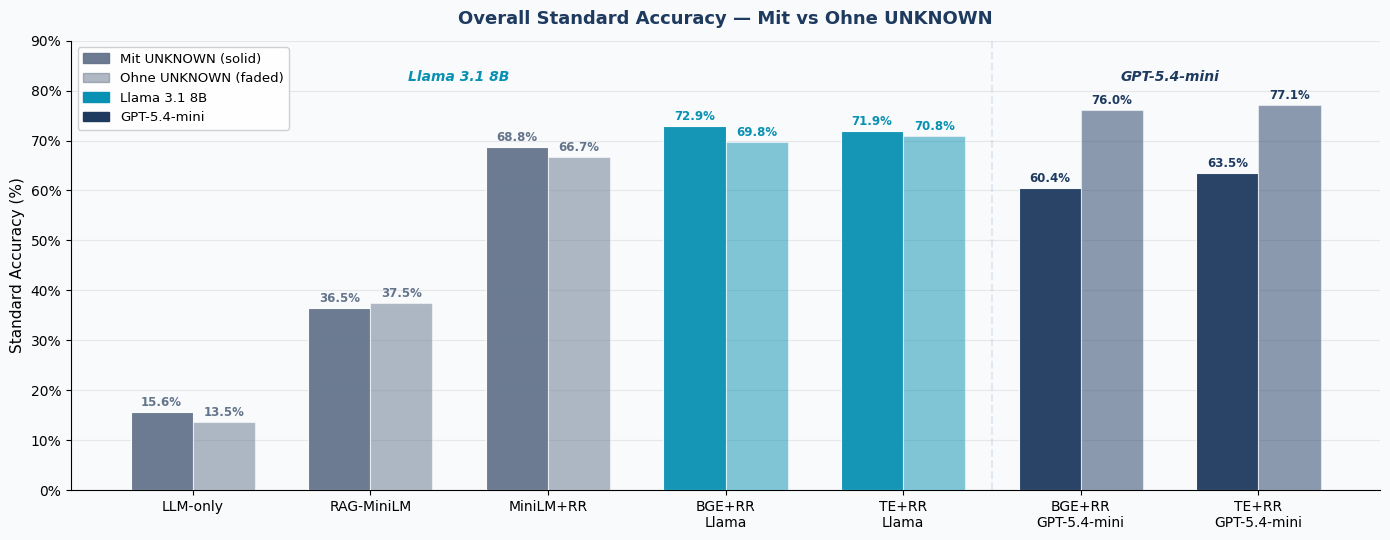

✓ fig_overall_mit_ohne.png


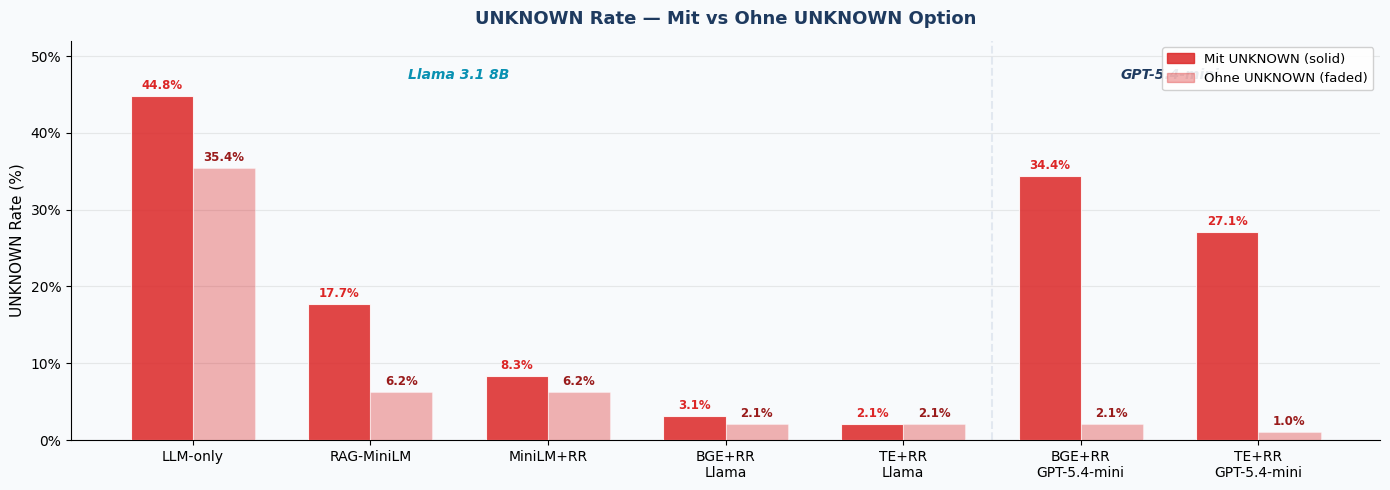

✓ fig_unknown_comparison.png


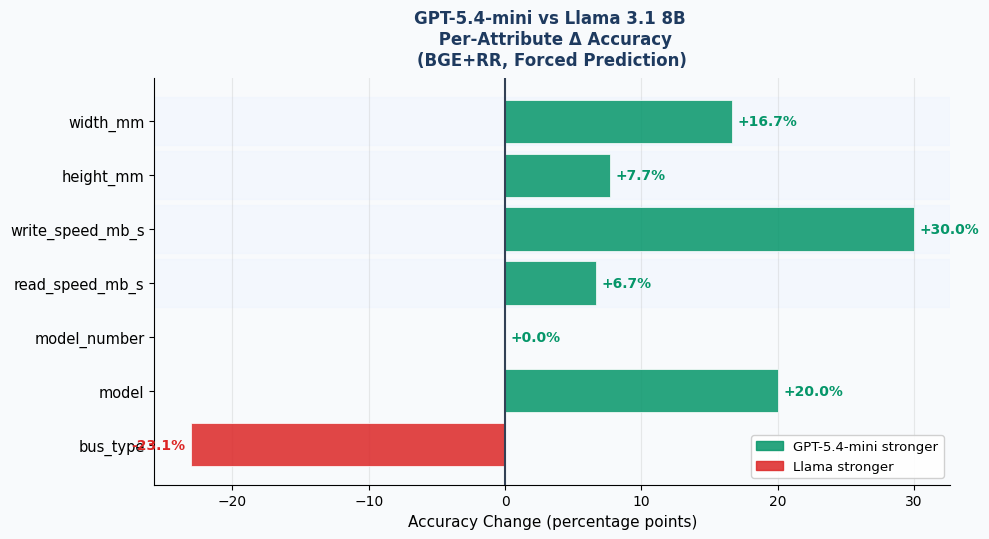

✓ fig_llm_delta.png


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import os

NUMERIC   = {'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm'}
FIGURES   = 'figures'
os.makedirs(FIGURES, exist_ok=True)

NAVY  = '#1E3A5F'; TEAL  = '#0891B2'; GREEN = '#059669'
RED   = '#DC2626'; GREY  = '#64748B'; GREYL = '#E2E8F0'
GREYC = '#F8FAFC'; ORANGE= '#D97706'

def fix(p):
    if isinstance(p,str) and p.strip().upper().startswith('VALUE:'):
        v = p.strip().split(':',1)[1].strip()
        return 'UNKNOWN' if v.upper() in {'UNKNOWN','NONE','NULL','NAN',''} else v
    return p

def is_unk(v):
    return str(v).strip().lower() in {'unknown','nan','none','null',''}

def correct(pred, gt, attr):
    if is_unk(pred): return False
    if attr in NUMERIC:
        try: return float(str(pred).replace(',','')) == float(str(gt).replace(',',''))
        except: return False
    p, g = str(pred).lower().strip(), str(gt).lower().strip()
    return p==g or p in g or g in p

def load(path):
    df = pd.read_csv(path)
    df['predicted'] = df['predicted'].apply(fix)
    df['correct']   = df.apply(lambda r: correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
    df['unk']       = df['predicted'].apply(is_unk)
    return df

# ── Load all files ─────────────────────────────────────────────────────────────
MIT  = 'results_mit_UNKNOWN'
OHNE = 'results_ohne_UNKNOWN'

configs = [
    ('LLM-only',           f'{MIT}/exp1_llm_only.csv',              f'{OHNE}/exp1_llm_only.csv'),
    ('RAG-MiniLM',         f'{MIT}/exp2_rag_minilm.csv',            f'{OHNE}/exp2_rag_minilm.csv'),
    ('MiniLM+RR',          f'{MIT}/exp3_rag_minilm_reranker.csv',   f'{OHNE}/exp3_rag_minilm_reranker.csv'),
    ('BGE+RR\nLlama',      f'{MIT}/exp4_rag_bge_reranker.csv',      f'{OHNE}/exp4_rag_bge_reranker.csv'),
    ('TE+RR\nLlama',       f'{MIT}/exp5_rag_te_reranker.csv',       f'{OHNE}/exp5_rag_te_reranker.csv'),
    ('BGE+RR\nGPT-5.4-mini',f'{MIT}/exp6_bge_reranker_gpt54mini.csv', f'{OHNE}/exp6_bge_reranker_gpt54mini.csv'),
    ('TE+RR\nGPT-5.4-mini', f'{MIT}/exp7_te_reranker_gpt54mini.csv',  f'{OHNE}/exp7_te_reranker_gpt54mini.csv'),
]

data = []
for label, mit_path, ohne_path in configs:
    dm = load(mit_path)
    do = load(ohne_path)
    data.append({
        'label':    label,
        'mit_acc':  dm['correct'].mean()*100,
        'mit_unk':  dm['unk'].mean()*100,
        'ohne_acc': do['correct'].mean()*100,
        'ohne_unk': do['unk'].mean()*100,
    })
df_summary = pd.DataFrame(data)

labels   = df_summary['label'].tolist()
mit_acc  = df_summary['mit_acc'].tolist()
ohne_acc = df_summary['ohne_acc'].tolist()
mit_unk  = df_summary['mit_unk'].tolist()
ohne_unk = df_summary['ohne_unk'].tolist()

# ── Color helpers ─────────────────────────────────────────────────────────────
# Llama = teal family, GPT = navy family
BAR_COLORS = [GREY, GREY, GREY, TEAL, TEAL, NAVY, NAVY]

# ════════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Overall accuracy mit vs ohne
# ════════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5.5))
fig.patch.set_facecolor(GREYC)
ax.set_facecolor(GREYC)

x = np.arange(len(labels)); w = 0.35

for i in range(len(labels)):
    b1 = ax.bar(i-w/2, mit_acc[i],  w, color=BAR_COLORS[i], alpha=0.95,
                edgecolor='white', linewidth=0.8, zorder=3)
    b2 = ax.bar(i+w/2, ohne_acc[i], w, color=BAR_COLORS[i], alpha=0.50,
                edgecolor='white', linewidth=0.8, zorder=3)
    ax.text(i-w/2, mit_acc[i]+0.6,  f'{mit_acc[i]:.1f}%',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold',
            color=BAR_COLORS[i])
    ax.text(i+w/2, ohne_acc[i]+0.6, f'{ohne_acc[i]:.1f}%',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold',
            color=BAR_COLORS[i])

# Divider between Llama and GPT groups
ax.axvline(4.5, color=GREYL, lw=1.5, linestyle='--', zorder=1)
ax.text(1.5, 82, 'Llama 3.1 8B', ha='center', fontsize=10,
        color=TEAL, fontweight='bold', style='italic')
ax.text(5.5, 82, 'GPT-5.4-mini', ha='center', fontsize=10,
        color=NAVY, fontweight='bold', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 90)
ax.set_ylabel('Standard Accuracy (%)', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Overall Standard Accuracy — Mit vs Ohne UNKNOWN',
             fontsize=13, fontweight='bold', color=NAVY, pad=12)
ax.grid(axis='y', alpha=0.25, zorder=0)
ax.spines[['top','right']].set_visible(False)

mit_patch  = mpatches.Patch(color=GREY, alpha=0.95, label='Mit UNKNOWN (solid)')
ohne_patch = mpatches.Patch(color=GREY, alpha=0.50, label='Ohne UNKNOWN (faded)')
teal_patch = mpatches.Patch(color=TEAL, label='Llama 3.1 8B')
navy_patch = mpatches.Patch(color=NAVY, label='GPT-5.4-mini')
ax.legend(handles=[mit_patch, ohne_patch, teal_patch, navy_patch],
          fontsize=9.5, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.savefig(f'{FIGURES}/fig_overall_mit_ohne.png', dpi=150,
            bbox_inches='tight', facecolor=GREYC)
plt.show()
print('✓ fig_overall_mit_ohne.png')

# ════════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — UNKNOWN rate mit vs ohne
# ════════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(GREYC)
ax.set_facecolor(GREYC)

for i in range(len(labels)):
    ax.bar(i-w/2, mit_unk[i],  w, color=RED,  alpha=0.85,
           edgecolor='white', linewidth=0.8, zorder=3)
    ax.bar(i+w/2, ohne_unk[i], w, color=RED,  alpha=0.35,
           edgecolor='white', linewidth=0.8, zorder=3)
    if mit_unk[i] > 0:
        ax.text(i-w/2, mit_unk[i]+0.5, f'{mit_unk[i]:.1f}%',
                ha='center', va='bottom', fontsize=8.5,
                fontweight='bold', color=RED)
    if ohne_unk[i] > 0:
        ax.text(i+w/2, ohne_unk[i]+0.5, f'{ohne_unk[i]:.1f}%',
                ha='center', va='bottom', fontsize=8.5,
                fontweight='bold', color='#991B1B')

ax.axvline(4.5, color=GREYL, lw=1.5, linestyle='--', zorder=1)
ax.text(1.5, 47, 'Llama 3.1 8B', ha='center', fontsize=10,
        color=TEAL, fontweight='bold', style='italic')
ax.text(5.5, 47, 'GPT-5.4-mini', ha='center', fontsize=10,
        color=NAVY, fontweight='bold', style='italic')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 52)
ax.set_ylabel('UNKNOWN Rate (%)', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('UNKNOWN Rate — Mit vs Ohne UNKNOWN Option',
             fontsize=13, fontweight='bold', color=NAVY, pad=12)
ax.grid(axis='y', alpha=0.25, zorder=0)
ax.spines[['top','right']].set_visible(False)

mit_p  = mpatches.Patch(color=RED, alpha=0.85, label='Mit UNKNOWN (solid)')
ohne_p = mpatches.Patch(color=RED, alpha=0.35, label='Ohne UNKNOWN (faded)')
ax.legend(handles=[mit_p, ohne_p], fontsize=9.5, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig(f'{FIGURES}/fig_unknown_comparison.png', dpi=150,
            bbox_inches='tight', facecolor=GREYC)
plt.show()
print('✓ fig_unknown_comparison.png')

# ════════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — LLM delta: GPT-5.4-mini minus Llama (ohne, BGE+RR)
# ════════════════════════════════════════════════════════════════════════════════
llama_ohne = load(f'{OHNE}/exp4_rag_bge_reranker.csv')
gpt_ohne   = load(f'{OHNE}/exp6_bge_reranker_gpt54mini.csv')

ATTRS = ['bus_type','model','model_number',
         'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm']
ATTR_LABELS = ['bus_type','model','model_number',
               'read_speed\n_mb_s','write_speed\n_mb_s','height_mm','width_mm']

deltas = []
for attr in ATTRS:
    l = llama_ohne[llama_ohne['attribute']==attr]['correct'].mean()*100
    g = gpt_ohne[gpt_ohne['attribute']==attr]['correct'].mean()*100
    deltas.append(g - l)

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor(GREYC)
ax.set_facecolor(GREYC)

colors = [GREEN if d >= 0 else RED for d in deltas]
y = np.arange(len(ATTRS))
bars = ax.barh(y, deltas, color=colors, alpha=0.85,
               edgecolor='white', linewidth=0.6, zorder=3)

for i, v in enumerate(deltas):
    ax.text(v + (0.4 if v >= 0 else -0.4), i,
            f'{v:+.1f}%', va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=10, fontweight='bold',
            color=GREEN if v >= 0 else RED)

# Shade numeric attributes
for i, attr in enumerate(ATTRS):
    if attr in NUMERIC:
        ax.axhspan(i-0.45, i+0.45, color='#EFF6FF', alpha=0.5, zorder=1)

ax.set_yticks(y)
ax.set_yticklabels(ATTRS, fontsize=10.5)
ax.axvline(0, color='#334155', lw=1.5, zorder=4)
ax.set_xlabel('Accuracy Change (percentage points)', fontsize=11)
ax.set_title('GPT-5.4-mini vs Llama 3.1 8B \n Per-Attribute Δ Accuracy\n'
             '(BGE+RR, Forced Prediction)',
             fontsize=12, fontweight='bold', color=NAVY, pad=10)
ax.grid(axis='x', alpha=0.25, zorder=0)
ax.spines[['top','right']].set_visible(False)

greenp = mpatches.Patch(color=GREEN, alpha=0.85, label='GPT-5.4-mini stronger')
redp   = mpatches.Patch(color=RED,   alpha=0.85, label='Llama stronger')

ax.legend(handles=[greenp, redp], fontsize=9.5,
          loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.savefig(f'{FIGURES}/fig_llm_delta.png', dpi=150,
            bbox_inches='tight', facecolor=GREYC)
plt.show()
print('✓ fig_llm_delta.png')


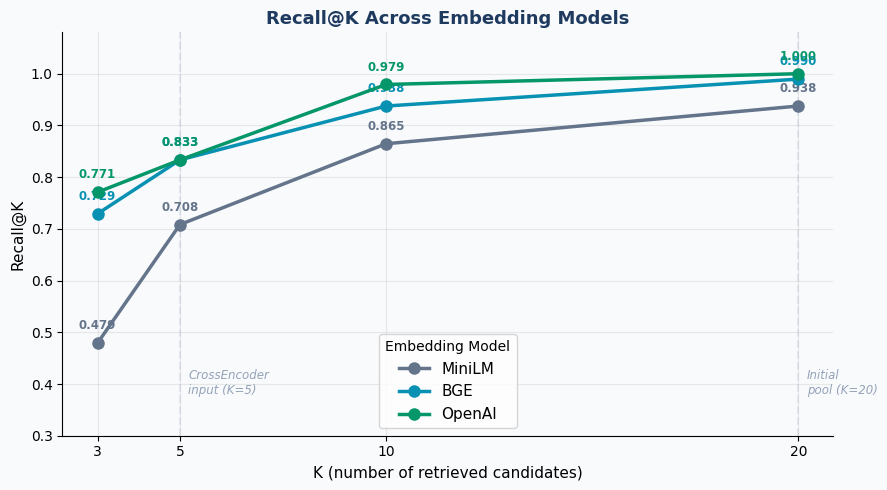

✓ fig_recall_main.png


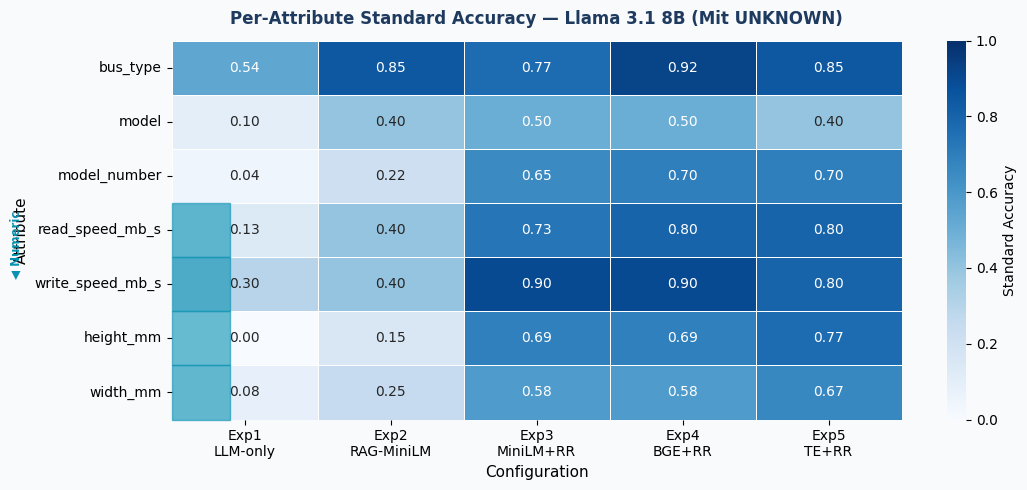

✓ fig_heatmap_llama.png


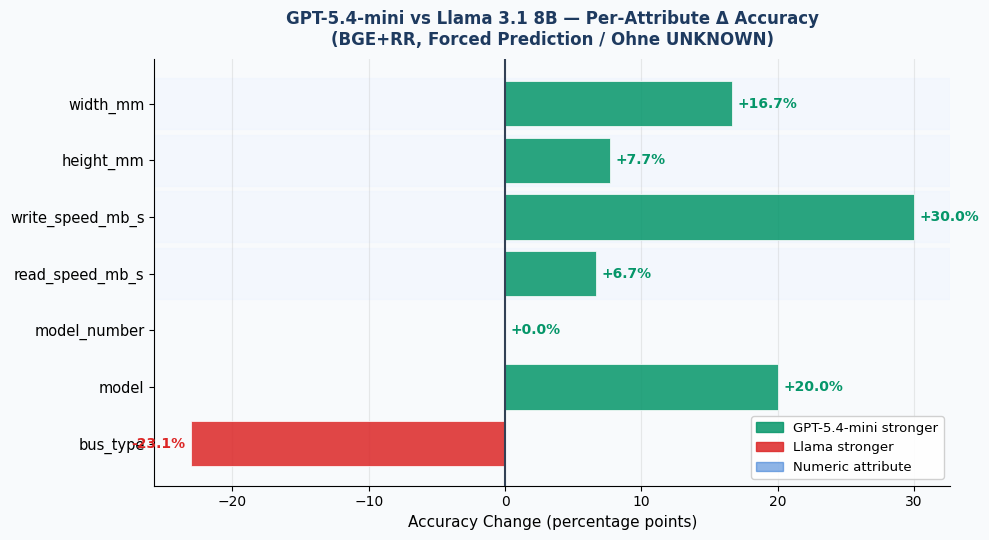

✓ fig_llm_delta.png

All 3 figures saved to figures/


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os

NUMERIC = {'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm'}
FIGURES = 'figures'
os.makedirs(FIGURES, exist_ok=True)

NAVY='#1E3A5F'; TEAL='#0891B2'; GREYC='#F8FAFC'; GREYL='#E2E8F0'
GREEN='#059669'; RED='#DC2626'

def fix(p):
    if isinstance(p,str) and p.strip().upper().startswith('VALUE:'):
        v=p.strip().split(':',1)[1].strip()
        return 'UNKNOWN' if v.upper() in {'UNKNOWN','NONE','NULL','NAN',''} else v
    return p

def is_unk(v): return str(v).strip().lower() in {'unknown','nan','none','null',''}

def correct(pred,gt,attr):
    if is_unk(pred): return False
    if attr in NUMERIC:
        try: return float(str(pred).replace(',',''))==float(str(gt).replace(',',''))
        except: return False
    p,g=str(pred).lower().strip(),str(gt).lower().strip()
    return p==g or p in g or g in p

def load(path):
    df=pd.read_csv(path)
    df['predicted']=df['predicted'].apply(fix)
    df['correct']=df.apply(lambda r: correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
    df['unk']=df['predicted'].apply(is_unk)
    return df

MIT='results_mit_UNKNOWN'

# ════════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Recall@K line chart
# ════════════════════════════════════════════════════════════════════════════════
retrieval = pd.read_csv(f'{MIT}/retrieval_metrics.csv')

COLORS = {'MiniLM': '#64748B', 'BGE': '#0891B2', 'OpenAI': '#059669'}
K_VALS = sorted(retrieval['k'].unique())

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(GREYC)
ax.set_facecolor(GREYC)

for model, color in COLORS.items():
    sub = retrieval[retrieval['model']==model].sort_values('k')
    ax.plot(sub['k'], sub['recall'], 'o-', color=color, lw=2.5,
            markersize=8, label=model, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(f'{row["recall"]:.3f}',
                    (row['k'], row['recall']),
                    textcoords='offset points', xytext=(0,10),
                    ha='center', fontsize=8.5, color=color,
                    fontweight='bold')

# Pipeline reference lines
ax.axvline(5,  color=GREYL, lw=1.5, linestyle='--', zorder=1)
ax.axvline(20, color=GREYL, lw=1.5, linestyle='--', zorder=1)
ax.text(5.2,  0.38, 'CrossEncoder\ninput (K=5)',
        fontsize=8.5, color='#94A3B8', style='italic')
ax.text(20.2, 0.38, 'Initial\npool (K=20)',
        fontsize=8.5, color='#94A3B8', style='italic')

ax.set_xticks(K_VALS)
ax.set_xlabel('K (number of retrieved candidates)', fontsize=11)
ax.set_ylabel('Recall@K', fontsize=11)
ax.set_ylim(0.3, 1.08)
ax.set_title('Recall@K Across Embedding Models',
             fontsize=13, fontweight='bold', color=NAVY)
ax.legend(fontsize=11, title='Embedding Model', title_fontsize=10)
ax.grid(alpha=0.25); ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIGURES}/fig_recall_main.png', dpi=150,
            bbox_inches='tight', facecolor=GREYC)
plt.show()
print('✓ fig_recall_main.png')

# ════════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Per-attribute heatmap (Llama mit UNKNOWN, standard accuracy)
# ════════════════════════════════════════════════════════════════════════════════
llama_files = [
    ('Exp1\nLLM-only',    f'{MIT}/exp1_llm_only.csv'),
    ('Exp2\nRAG-MiniLM',  f'{MIT}/exp2_rag_minilm.csv'),
    ('Exp3\nMiniLM+RR',   f'{MIT}/exp3_rag_minilm_reranker.csv'),
    ('Exp4\nBGE+RR',      f'{MIT}/exp4_rag_bge_reranker.csv'),
    ('Exp5\nTE+RR',       f'{MIT}/exp5_rag_te_reranker.csv'),
]

ATTRS = ['bus_type','model','model_number',
         'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm']

heatmap_data = pd.DataFrame(index=ATTRS,
                             columns=[l for l,_ in llama_files])
for label, path in llama_files:
    df = load(path)
    for attr in ATTRS:
        sub = df[df['attribute']==attr]
        heatmap_data.loc[attr, label] = round(sub['correct'].mean(), 3)
heatmap_data = heatmap_data.astype(float)

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(GREYC)

sns.heatmap(heatmap_data, annot=True, fmt='.2f',
            cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Standard Accuracy'})

# Mark numeric rows with a left bar
for i, attr in enumerate(ATTRS):
    if attr in NUMERIC:
        ax.add_patch(plt.Rectangle((0, i), 0.08, 1,
                     fill=True, color=TEAL, alpha=0.6,
                     transform=ax.get_yaxis_transform(),
                     clip_on=False, zorder=5))

ax.set_title('Per-Attribute Standard Accuracy — Llama 3.1 8B (Mit UNKNOWN)',
             fontsize=12, fontweight='bold', color=NAVY, pad=12)
ax.set_xlabel('Configuration', fontsize=11)
ax.set_ylabel('Attribute', fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

fig.text(0.01, 0.5, '◀ Numeric', va='center', rotation=90,
         fontsize=8.5, color=TEAL, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES}/fig_heatmap_llama.png', dpi=150,
            bbox_inches='tight', facecolor=GREYC)
plt.show()
print('✓ fig_heatmap_llama.png')

# ════════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — LLM delta: GPT-5.4-mini minus Llama (ohne, BGE+RR)
# already in previous code but regenerate cleanly here
# ════════════════════════════════════════════════════════════════════════════════
OHNE = 'results_ohne_UNKNOWN'
llama_ohne = load(f'{OHNE}/exp4_rag_bge_reranker.csv')
gpt_ohne   = load(f'{OHNE}/exp6_bge_reranker_gpt54mini.csv')

deltas = []
for attr in ATTRS:
    l = llama_ohne[llama_ohne['attribute']==attr]['correct'].mean()*100
    g = gpt_ohne[gpt_ohne['attribute']==attr]['correct'].mean()*100
    deltas.append(g - l)

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor(GREYC)
ax.set_facecolor(GREYC)

colors = [GREEN if d >= 0 else RED for d in deltas]
y = np.arange(len(ATTRS))
ax.barh(y, deltas, color=colors, alpha=0.85,
        edgecolor='white', linewidth=0.6, zorder=3)

for i, v in enumerate(deltas):
    ax.text(v+(0.4 if v>=0 else -0.4), i, f'{v:+.1f}%',
            va='center', ha='left' if v>=0 else 'right',
            fontsize=10, fontweight='bold',
            color=GREEN if v>=0 else RED)

# Shade numeric attributes
for i, attr in enumerate(ATTRS):
    if attr in NUMERIC:
        ax.axhspan(i-0.45, i+0.45, color='#EFF6FF', alpha=0.5, zorder=1)

ax.set_yticks(y); ax.set_yticklabels(ATTRS, fontsize=10.5)
ax.axvline(0, color='#334155', lw=1.5, zorder=4)
ax.set_xlabel('Accuracy Change (percentage points)', fontsize=11)
ax.set_title('GPT-5.4-mini vs Llama 3.1 8B — Per-Attribute Δ Accuracy\n'
             '(BGE+RR, Forced Prediction / Ohne UNKNOWN)',
             fontsize=12, fontweight='bold', color=NAVY, pad=10)
ax.grid(axis='x', alpha=0.25, zorder=0)
ax.spines[['top','right']].set_visible(False)

import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color=GREEN, alpha=0.85, label='GPT-5.4-mini stronger'),
    mpatches.Patch(color=RED,   alpha=0.85, label='Llama stronger'),
    mpatches.Patch(color="#1F6CD0", alpha=0.5, label='Numeric attribute'),
], fontsize=9.5, loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.savefig(f'{FIGURES}/fig_llm_delta.png', dpi=150,
            bbox_inches='tight', facecolor=GREYC)
plt.show()
print('✓ fig_llm_delta.png')

print('\nAll 3 figures saved to figures/')

In [7]:
import pandas as pd
import numpy as np

NUMERIC = {'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm'}
MIT  = 'results_mit_UNKNOWN'
OHNE = 'results_ohne_UNKNOWN'

def fix(p):
    if isinstance(p,str) and p.strip().upper().startswith('VALUE:'):
        v=p.strip().split(':',1)[1].strip()
        return 'UNKNOWN' if v.upper() in {'UNKNOWN','NONE','NULL','NAN',''} else v
    return p

def is_unk(v): return str(v).strip().lower() in {'unknown','nan','none','null',''}

def correct(pred,gt,attr):
    if is_unk(pred): return False
    if attr in NUMERIC:
        try: return float(str(pred).replace(',',''))==float(str(gt).replace(',',''))
        except: return False
    p,g=str(pred).lower().strip(),str(gt).lower().strip()
    return p==g or p in g or g in p

def load(path):
    df=pd.read_csv(path)
    df['predicted']=df['predicted'].apply(fix)
    df['correct']=df.apply(lambda r: correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
    df['unk']=df['predicted'].apply(is_unk)
    return df

configs = [
    ('LLM-only',
     f'{MIT}/exp1_llm_only.csv',
     f'{OHNE}/exp1_llm_only.csv'),
    ('RAG-MiniLM',
     f'{MIT}/exp2_rag_minilm.csv',
     f'{OHNE}/exp2_rag_minilm.csv'),
    ('MiniLM + Reranker',
     f'{MIT}/exp3_rag_minilm_reranker.csv',
     f'{OHNE}/exp3_rag_minilm_reranker.csv'),
    ('BGE + Reranker (Llama)',
     f'{MIT}/exp4_rag_bge_reranker.csv',
     f'{OHNE}/exp4_rag_bge_reranker.csv'),
    ('TE + Reranker (Llama)',
     f'{MIT}/exp5_rag_te_reranker.csv',
     f'{OHNE}/exp5_rag_te_reranker.csv'),
    ('BGE + Reranker (GPT-5.4-mini)',
     f'{MIT}/exp6_bge_reranker_gpt54mini.csv',   # no hyphen
     f'{OHNE}/exp6_bge_reranker_gpt54mini.csv'),  # no hyphen
    ('TE + Reranker (GPT-5.4-mini)',
     f'{MIT}/exp7_te_reranker_gpt54mini.csv',    # no hyphen
     f'{OHNE}/exp7_te_reranker_gpt54mini.csv'),   # no hyphen
]

ATTRS = ['bus_type','model','model_number',
         'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm']

# ── Table 1: Permitted abstention ─────────────────────────────────────────────
print('='*55)
print('TABLE 1 — Permitted Abstention (UNKNOWN allowed)')
print('='*55)
print(f'  {"Configuration":<32} {"Accuracy":>9} {"Abstention":>11}')
print('-'*55)
for label, mit_path, _ in configs:
    df = load(mit_path)
    acc = df['correct'].mean()*100
    unk = df['unk'].mean()*100
    print(f'  {label:<32} {acc:>8.1f}% {unk:>10.1f}%')

# ── Table 2: Forced prediction ────────────────────────────────────────────────
print(f'\n{"="*55}')
print('TABLE 2 — Forced Prediction (UNKNOWN disallowed)')
print('='*55)
print(f'  {"Configuration":<32} {"Accuracy":>9} {"Abstention":>11}')
print('-'*55)
for label, _, ohne_path in configs:
    df = load(ohne_path)
    acc = df['correct'].mean()*100
    unk = df['unk'].mean()*100
    print(f'  {label:<32} {acc:>8.1f}% {unk:>10.1f}%')

# ── Table 3: Comparison delta ─────────────────────────────────────────────────
print(f'\n{"="*70}')
print('TABLE 3 — Permitted vs Forced Comparison')
print('='*70)
print(f'  {"Configuration":<32} {"Perm Acc":>9} {"Perm Abst":>10} '
      f'{"Forced Acc":>11} {"Delta":>7}')
print('-'*70)
for label, mit_path, ohne_path in configs:
    dm = load(mit_path);  do = load(ohne_path)
    m_acc=dm['correct'].mean()*100; m_unk=dm['unk'].mean()*100
    o_acc=do['correct'].mean()*100
    delta=o_acc-m_acc
    print(f'  {label:<32} {m_acc:>8.1f}% {m_unk:>9.1f}% '
          f'{o_acc:>10.1f}% {delta:>+6.1f}%')

# ── Per-attribute table (Llama mit) ──────────────────────────────────────────
print(f'\n{"="*80}')
print('TABLE 4 — Per-Attribute Accuracy (Llama, Permitted Abstention)')
print('='*80)
llama_files = [
    ('Exp1', f'{MIT}/exp1_llm_only.csv'),
    ('Exp2', f'{MIT}/exp2_rag_minilm.csv'),
    ('Exp3', f'{MIT}/exp3_rag_minilm_reranker.csv'),
    ('Exp4', f'{MIT}/exp4_rag_bge_reranker.csv'),
    ('Exp5', f'{MIT}/exp5_rag_te_reranker.csv'),
]
header = f'  {"Attribute":<25} {"Type":<8}' + ''.join(f'{l:>8}' for l,_ in llama_files)
print(header)
print('-'*80)
for attr in ATTRS:
    t = 'numeric' if attr in NUMERIC else 'text'
    row = f'  {attr:<25} {t:<8}'
    for label, path in llama_files:
        df = load(path)
        sub = df[df['attribute']==attr]
        row += f'{sub["correct"].mean()*100:>7.1f}%'
    print(row)

# ── LLM comparison table (BGE+RR ohne) ───────────────────────────────────────
print(f'\n{"="*65}')
print('TABLE 5 — LLM Comparison on BGE+RR (Forced Prediction)')
print('='*65)
llm_files = [
    ('Llama 3.1 8B',    f'{OHNE}/exp4_rag_bge_reranker.csv'),
    ('GPT-5.4-mini',    f'{OHNE}/exp6_bge_reranker_gpt54mini.csv'),
]
print(f'  {"Attribute":<25} {"Type":<8}' +
      ''.join(f'{l:>16}' for l,_ in llm_files))
print('-'*65)
for attr in ATTRS:
    t = 'numeric' if attr in NUMERIC else 'text'
    row = f'  {attr:<25} {t:<8}'
    for label, path in llm_files:
        df = load(path)
        sub = df[df['attribute']==attr]
        row += f'{sub["correct"].mean()*100:>15.1f}%'
    print(row)
print('-'*65)
for label2, (label, path) in zip(['Overall','Numeric avg','Text avg'],
    [('all', None), ('numeric', None), ('text', None)]):
    row = f'  {label2:<25} {"":8}'
    for lbl, p in llm_files:
        df = load(p)
        if label2 == 'Overall':
            val = df['correct'].mean()*100
        elif label2 == 'Numeric avg':
            val = df[df['attribute'].isin(NUMERIC)]['correct'].mean()*100
        else:
            val = df[~df['attribute'].isin(NUMERIC)]['correct'].mean()*100
        row += f'{val:>15.1f}%'
    print(row)
unk_row = f'  {"Abstention rate":<25} {"":8}'
for lbl, p in llm_files:
    df = load(p)
    unk_row += f'{df["unk"].mean()*100:>15.1f}%'
print(unk_row)

TABLE 1 — Permitted Abstention (UNKNOWN allowed)
  Configuration                     Accuracy  Abstention
-------------------------------------------------------
  LLM-only                             15.6%       44.8%
  RAG-MiniLM                           36.5%       17.7%
  MiniLM + Reranker                    68.8%        8.3%
  BGE + Reranker (Llama)               72.9%        3.1%
  TE + Reranker (Llama)                71.9%        2.1%
  BGE + Reranker (GPT-5.4-mini)        60.4%       34.4%
  TE + Reranker (GPT-5.4-mini)         63.5%       27.1%

TABLE 2 — Forced Prediction (UNKNOWN disallowed)
  Configuration                     Accuracy  Abstention
-------------------------------------------------------
  LLM-only                             13.5%       35.4%
  RAG-MiniLM                           37.5%        6.2%
  MiniLM + Reranker                    66.7%        6.2%
  BGE + Reranker (Llama)               69.8%        2.1%
  TE + Reranker (Llama)                70.8%    

In [1]:
import pandas as pd

NUMERIC = {'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm'}
MIT  = 'results_mit_UNKNOWN'
OHNE = 'results_ohne_UNKNOWN'

def fix(p):
    if isinstance(p,str) and p.strip().upper().startswith('VALUE:'):
        v=p.strip().split(':',1)[1].strip()
        return 'UNKNOWN' if v.upper() in {'UNKNOWN','NONE','NULL','NAN',''} else v
    return p

def is_unk(v): return str(v).strip().lower() in {'unknown','nan','none','null',''}

def correct(pred,gt,attr):
    if is_unk(pred): return False
    if attr in NUMERIC:
        try: return float(str(pred).replace(',',''))==float(str(gt).replace(',',''))
        except: return False
    p,g=str(pred).lower().strip(),str(gt).lower().strip()
    return p==g or p in g or g in p

# Load best local config — TE+RR Llama mit UNKNOWN
df = pd.read_csv(f'{MIT}/exp5_rag_te_reranker.csv')
df['predicted'] = df['predicted'].apply(fix)
df['correct']   = df.apply(lambda r: correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
df['unk']       = df['predicted'].apply(is_unk)

errors = df[~df['correct']].copy()
print(f'Total tasks: {len(df)}')
print(f'Correct: {df["correct"].sum()}')
print(f'Wrong (including UNKNOWN): {len(errors)}')
print(f'  of which UNKNOWN: {errors["unk"].sum()}')
print(f'  of which wrong value: {(~errors["correct"] & ~errors["unk"]).sum()}')

print(f'\n=== ALL ERRORS ===')
print(f'{"Row":<6}{"Attr":<25}{"GT":<25}{"Predicted":<30}{"UNK"}')
print('='*95)
for _,r in errors.iterrows():
    unk = 'Y' if r['unk'] else 'N'
    print(f'{int(r["df1_idx"]):<6}{r["attribute"]:<25}{str(r["ground_truth"]):<25}{str(r["predicted"]):<30}{unk}')

print(f'\n=== ERRORS BY ATTRIBUTE ===')
print(errors.groupby('attribute').agg(
    total_errors=('correct','count'),
    unknown=('unk','sum'),
    wrong_value=('unk', lambda x: (~x).sum())
).to_string())

# Also load best GPT config for comparison
df_gpt = pd.read_csv(f'{OHNE}/exp6_bge_reranker_gpt54mini.csv')
df_gpt['predicted'] = df_gpt['predicted'].apply(fix)
df_gpt['correct']   = df_gpt.apply(lambda r: correct(r['predicted'],r['ground_truth'],r['attribute']),axis=1)
df_gpt['unk']       = df_gpt['predicted'].apply(is_unk)

errors_gpt = df_gpt[~df_gpt['correct']].copy()
print(f'\n=== GPT-5.4-mini (BGE+RR ohne) ERRORS ===')
print(f'Total errors: {len(errors_gpt)} | UNKNOWN: {errors_gpt["unk"].sum()} | Wrong value: {(~errors_gpt["correct"] & ~errors_gpt["unk"]).sum()}')

# Cases where Llama wrong but GPT correct and vice versa
merged = df[['df1_idx','attribute','ground_truth','correct','unk']].copy()
merged.columns = ['df1_idx','attribute','ground_truth','llama_correct','llama_unk']
merged['gpt_correct'] = df_gpt['correct'].values
merged['gpt_unk']     = df_gpt['unk'].values

llama_only = merged[merged['llama_correct'] & ~merged['gpt_correct']]
gpt_only   = merged[~merged['llama_correct'] & merged['gpt_correct']]

print(f'\nLlama correct, GPT wrong: {len(llama_only)}')
print(f'GPT correct, Llama wrong: {len(gpt_only)}')
print(f'\nAttributes where GPT beats Llama:')
print(gpt_only.groupby('attribute')['gpt_correct'].count().sort_values(ascending=False).to_string())
print(f'\nAttributes where Llama beats GPT:')
print(llama_only.groupby('attribute')['llama_correct'].count().sort_values(ascending=False).to_string())

Total tasks: 96
Correct: 69
Wrong (including UNKNOWN): 27
  of which UNKNOWN: 2
  of which wrong value: 25

=== ALL ERRORS ===
Row   Attr                     GT                       Predicted                     UNK
0     model_number             GV-N3080GAMING OC-10GD   GV-N3080EAGLE-OC-10GD         N
6     bus_type                 USB 3.0                  USB 3.1                       N
9     model_number             V375-040R                UNKNOWN                       Y
12    model_number             90YV0DQ0-M0NA00          GV-N2060SOE-8GD               N
15    bus_type                 PCIe 3.0 x16             PCIe 3.0 x8                   N
16    model_number             NE6166SS18J9-161F        NE51660018J9-165F             N
18    height_mm                7.0                      6.8                           N
19    model_number             ROG-STRIX-RTX2080TI-O11G-GAMINGROG Strix GeForce RTX™ 2080 Ti OC editionN
20    model                    220S                     HIGH S